In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
import os

print(os.getcwd())

c:\Users\ashwi\OneDrive\Desktop\ak code\env


In [6]:
os.listdir()

['.gitignore',
 'Amazon_Sales_Cleaned.csv',
 'bikessaleproject.ipynb',
 'Data_analayst_project.ipynb',
 'Include',
 'Lib',
 'machinelearning.ipynb',
 'pyvenv.cfg',
 'Scripts',
 'share',
 'zomato.ipynb']

In [13]:
df = pd.read_csv("bikesales.csv")
df.head()

,Bike_ID,Brand,Model,Year,Fuel_Type,Engine_CC,Price_INR,KM_Driven,Mileage_KMPL,City
0,BK10001,Suzuki,Access 125,2018.0,Petrol,300.0,35000.0,44423.0,63.7,Salem
1,BK10002,TVS,Apache RTR 160,2025.0,Petrol,200.0,63400.0,14266.0,48.3,Chennai
2,BK10003,Bajaj,Pulsar 150,2020.0,Petrol,350.0,47300.0,24959.0,37.8,Coimbatore
3,BK10004,Suzuki,Gixxer,2025.0,Petrol,160.0,108900.0,25980.0,41.3,Salem
4,BK10005,Royal Enfield,Classic 350,2017.0,Petrol,300.0,35000.0,65681.0,55.2,Salem


In [14]:
df.shape

(15000, 10)

In [16]:
df.columns

Index(['Bike_ID', 'Brand', 'Model', 'Year', 'Fuel_Type', 'Engine_CC',
       'Price_INR', 'KM_Driven', 'Mileage_KMPL', 'City'],
      dtype='str')

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Bike_ID       15000 non-null  str    
 1   Brand         14820 non-null  str    
 2   Model         14850 non-null  str    
 3   Year          14880 non-null  float64
 4   Fuel_Type     14820 non-null  str    
 5   Engine_CC     14775 non-null  float64
 6   Price_INR     14730 non-null  float64
 7   KM_Driven     14821 non-null  float64
 8   Mileage_KMPL  14775 non-null  float64
 9   City          14850 non-null  str    
dtypes: float64(5), str(5)
memory usage: 1.1 MB


In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
df = df.drop_duplicates()

In [20]:
df.isnull().sum()

Bike_ID           0
Brand           180
Model           150
Year            120
Fuel_Type       180
Engine_CC       225
Price_INR       270
KM_Driven       179
Mileage_KMPL    225
City            150
dtype: int64

In [21]:
(df.isnull().sum() / len(df)) * 100

Bike_ID         0.000000
Brand           1.200000
Model           1.000000
Year            0.800000
Fuel_Type       1.200000
Engine_CC       1.500000
Price_INR       1.800000
KM_Driven       1.193333
Mileage_KMPL    1.500000
City            1.000000
dtype: float64

In [22]:
df.select_dtypes(include="number").columns

Index(['Year', 'Engine_CC', 'Price_INR', 'KM_Driven', 'Mileage_KMPL'], dtype='str')

In [23]:
numeric_cols = df.select_dtypes(include="number").columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

In [24]:
text_cols = df.select_dtypes(include="object").columns

for col in text_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

C:\Users\ashwi\AppData\Local\Temp\ipykernel_10284\3748238423.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = df.select_dtypes(include="object").columns


In [25]:
df.isnull().sum()

Bike_ID         0
Brand           0
Model           0
Year            0
Fuel_Type       0
Engine_CC       0
Price_INR       0
KM_Driven       0
Mileage_KMPL    0
City            0
dtype: int64

In [26]:
df.dtypes

Bike_ID             str
Brand               str
Model               str
Year            float64
Fuel_Type           str
Engine_CC       float64
Price_INR       float64
KM_Driven       float64
Mileage_KMPL    float64
City                str
dtype: object

In [27]:
df.describe()

,Year,Engine_CC,Price_INR,KM_Driven,Mileage_KMPL
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,2021.054867,213.282333,84866.886667,45367.418267,48.085880
std,2.565442,99.848265,41295.124676,25470.958387,7.940394
min,2017.000000,100.000000,0.000000,-100.000000,25.000000
25%,2019.000000,125.000000,48000.000000,23428.500000,42.800000
50%,2021.000000,160.000000,80300.000000,45458.000000,48.100000
75%,2023.000000,300.000000,112200.000000,66941.250000,53.400000
max,2030.000000,400.000000,259900.000000,89994.000000,79.200000


In [28]:
df.duplicated().sum()

np.int64(0)

In [29]:
df.shape

(15000, 10)

In [30]:
df.to_excel("bikesales_cleaned.xlsx", index=False)

In [32]:
cleaned_df = pd.read_excel("bikesales_cleaned.xlsx")

print("Rows:", cleaned_df.shape[0])
print("Columns:", cleaned_df.shape[1])
print("Missing values:", cleaned_df.isnull().sum().sum())
print("Duplicates:", cleaned_df.duplicated().sum())

Rows: 15000
Columns: 10
Missing values: 0
Duplicates: 0


In [33]:
df = pd.read_excel("bikesales_cleaned.xlsx")

df.head()

,Bike_ID,Brand,Model,Year,Fuel_Type,Engine_CC,Price_INR,KM_Driven,Mileage_KMPL,City
0,BK10001,Suzuki,Access 125,2018,Petrol,300,35000,44423,63.7,Salem
1,BK10002,TVS,Apache RTR 160,2025,Petrol,200,63400,14266,48.3,Chennai
2,BK10003,Bajaj,Pulsar 150,2020,Petrol,350,47300,24959,37.8,Coimbatore
3,BK10004,Suzuki,Gixxer,2025,Petrol,160,108900,25980,41.3,Salem
4,BK10005,Royal Enfield,Classic 350,2017,Petrol,300,35000,65681,55.2,Salem


In [34]:
df.shape

(15000, 10)

In [35]:
df.isnull().sum()

Bike_ID         0
Brand           0
Model           0
Year            0
Fuel_Type       0
Engine_CC       0
Price_INR       0
KM_Driven       0
Mileage_KMPL    0
City            0
dtype: int64

In [36]:
df.duplicated().sum()

np.int64(0)

In [37]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Bike_ID       15000 non-null  str    
 1   Brand         15000 non-null  str    
 2   Model         15000 non-null  str    
 3   Year          15000 non-null  int64  
 4   Fuel_Type     15000 non-null  str    
 5   Engine_CC     15000 non-null  int64  
 6   Price_INR     15000 non-null  int64  
 7   KM_Driven     15000 non-null  int64  
 8   Mileage_KMPL  15000 non-null  float64
 9   City          15000 non-null  str    
dtypes: float64(1), int64(4), str(5)
memory usage: 1.1 MB


In [38]:
df.describe()

,Year,Engine_CC,Price_INR,KM_Driven,Mileage_KMPL
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,2021.054867,213.282333,84866.886667,45367.418267,48.085880
std,2.565442,99.848265,41295.124676,25470.958387,7.940394
min,2017.000000,100.000000,0.000000,-100.000000,25.000000
25%,2019.000000,125.000000,48000.000000,23428.500000,42.800000
50%,2021.000000,160.000000,80300.000000,45458.000000,48.100000
75%,2023.000000,300.000000,112200.000000,66941.250000,53.400000
max,2030.000000,400.000000,259900.000000,89994.000000,79.200000


In [39]:
df.dtypes

Bike_ID             str
Brand               str
Model               str
Year              int64
Fuel_Type           str
Engine_CC         int64
Price_INR         int64
KM_Driven         int64
Mileage_KMPL    float64
City                str
dtype: object

In [40]:
df.nunique()

Bike_ID         15000
Brand               8
Model              24
Year               10
Fuel_Type           2
Engine_CC          10
Price_INR        1645
KM_Driven       13604
Mileage_KMPL      471
City                8
dtype: int64

In [41]:
df["Brand"].value_counts()

Brand
Honda            2077
Yamaha           1897
Bajaj            1875
Suzuki           1851
Hero             1845
TVS              1844
Royal Enfield    1809
KTM              1802
Name: count, dtype: int64

In [42]:
df.groupby("Brand")["Price_INR"].mean()

Brand
Bajaj            84422.506667
Hero             85762.926829
Honda            85051.179586
KTM              85004.162042
Royal Enfield    83868.490879
Suzuki           84786.277688
TVS              85829.826464
Yamaha           84197.153400
Name: Price_INR, dtype: float64

In [43]:
df.groupby("Brand")["Mileage_KMPL"].mean()

Brand
Bajaj            47.940000
Hero             47.922168
Honda            48.166683
KTM              47.935683
Royal Enfield    48.019348
Suzuki           48.190222
TVS              48.220987
Yamaha           48.273801
Name: Mileage_KMPL, dtype: float64

In [44]:
df.groupby("Brand")["KM_Driven"].mean()

Brand
Bajaj            45161.216000
Hero             45547.015176
Honda            45690.148772
KTM              45632.471698
Royal Enfield    45784.728027
Suzuki           44434.137763
TVS              45864.729935
Yamaha           44820.703216
Name: KM_Driven, dtype: float64

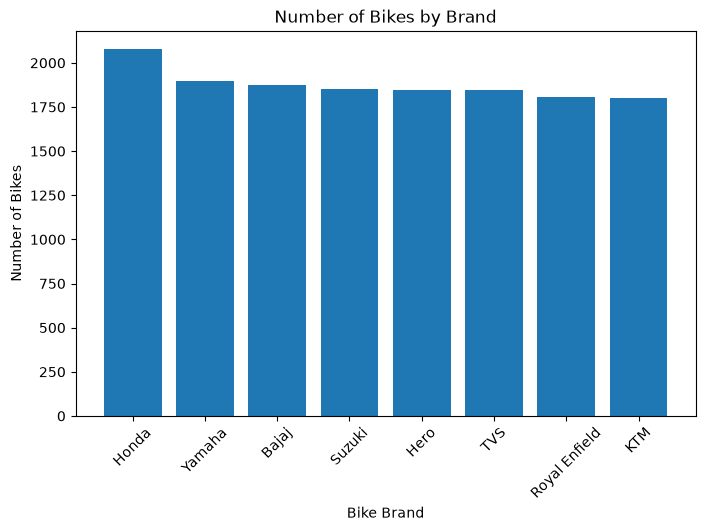

In [47]:
import matplotlib.pyplot as plt

brand_count = df["Brand"].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(brand_count.index, brand_count.values)

plt.xlabel("Bike Brand")
plt.ylabel("Number of Bikes")
plt.title("Number of Bikes by Brand")

plt.xticks(rotation=45)
plt.show()

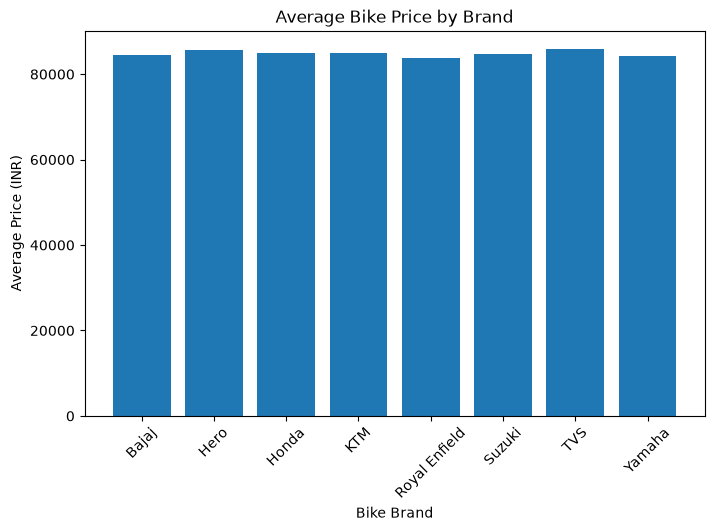

In [49]:
avg_price = df.groupby("Brand")["Price_INR"].mean()

plt.figure(figsize=(8, 5))
plt.bar(avg_price.index, avg_price.values)

plt.xlabel("Bike Brand")
plt.ylabel("Average Price (INR)")
plt.title("Average Bike Price by Brand")

plt.xticks(rotation=45)
plt.show()

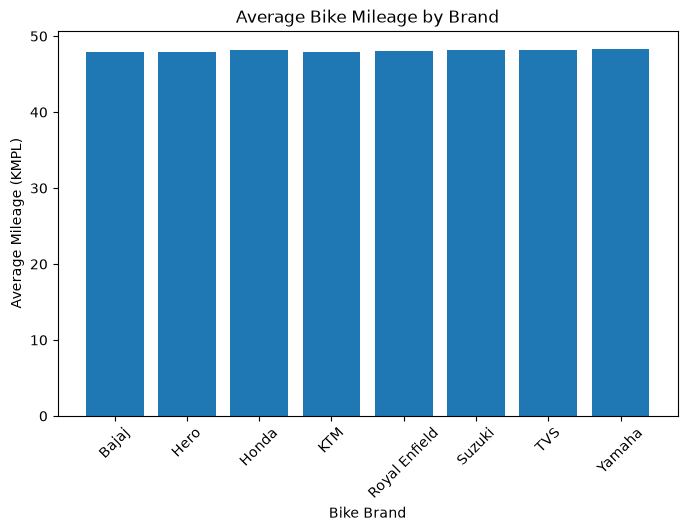

In [51]:
avg_mileage = df.groupby("Brand")["Mileage_KMPL"].mean()

plt.figure(figsize=(8, 5))
plt.bar(avg_mileage.index, avg_mileage.values)

plt.xlabel("Bike Brand")
plt.ylabel("Average Mileage (KMPL)")
plt.title("Average Bike Mileage by Brand")

plt.xticks(rotation=45)
plt.show()

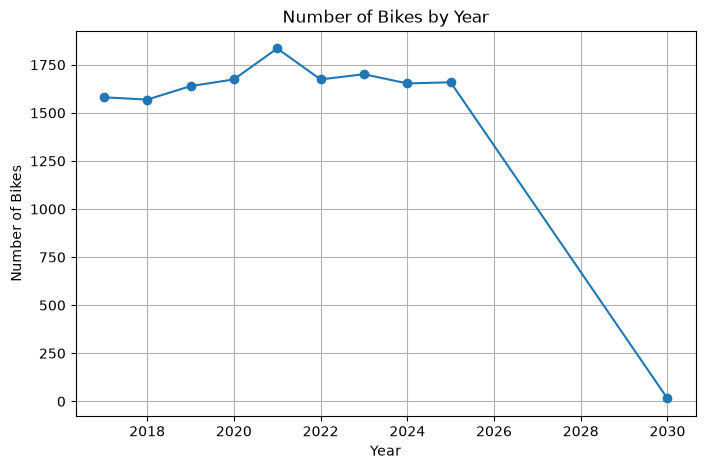

In [53]:
year_count = df["Year"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.plot(year_count.index, year_count.values, marker="o")

plt.xlabel("Year")
plt.ylabel("Number of Bikes")
plt.title("Number of Bikes by Year")

plt.grid(True)
plt.show()

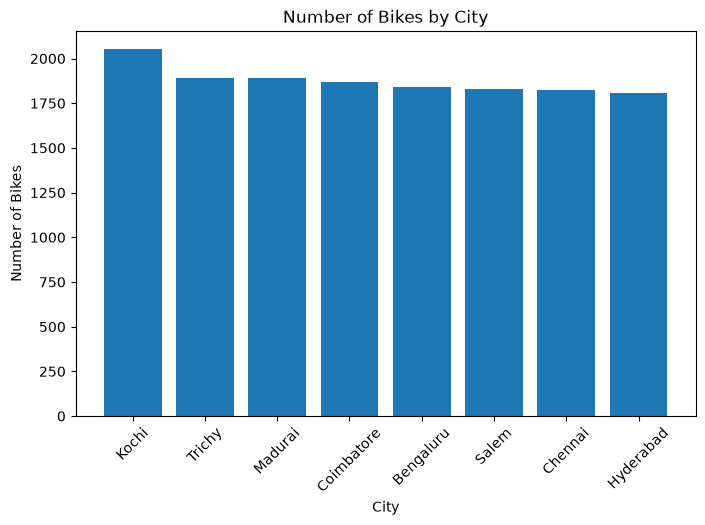

In [55]:
city_count = df["City"].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(city_count.index, city_count.values)

plt.xlabel("City")
plt.ylabel("Number of Bikes")
plt.title("Number of Bikes by City")

plt.xticks(rotation=45)
plt.show()

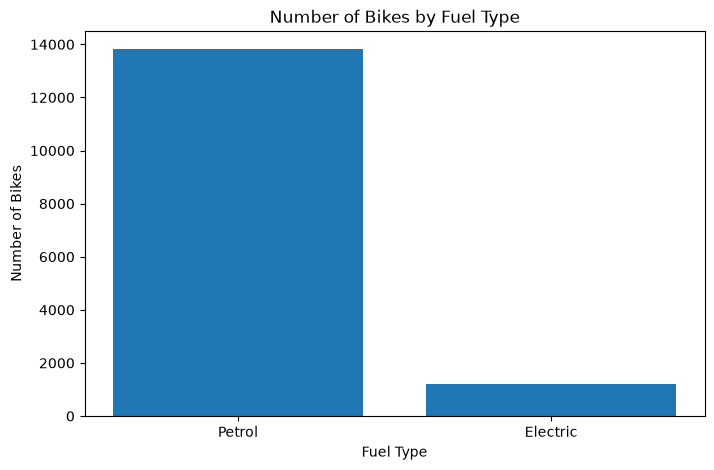

In [56]:
fuel_count = df["Fuel_Type"].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(fuel_count.index, fuel_count.values)

plt.xlabel("Fuel Type")
plt.ylabel("Number of Bikes")
plt.title("Number of Bikes by Fuel Type")

plt.show()

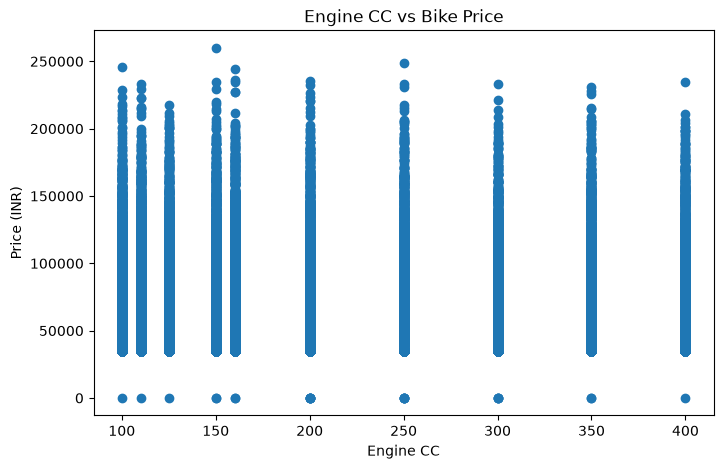

In [57]:
plt.figure(figsize=(8, 5))

plt.scatter(df["Engine_CC"], df["Price_INR"])

plt.xlabel("Engine CC")
plt.ylabel("Price (INR)")
plt.title("Engine CC vs Bike Price")

plt.show()

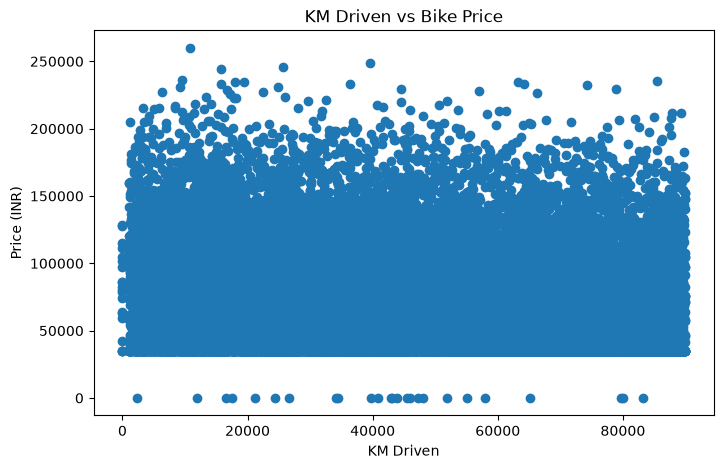

In [59]:
plt.figure(figsize=(8, 5))

plt.scatter(df["KM_Driven"], df["Price_INR"])

plt.xlabel("KM Driven")
plt.ylabel("Price (INR)")
plt.title("KM Driven vs Bike Price")

plt.show()

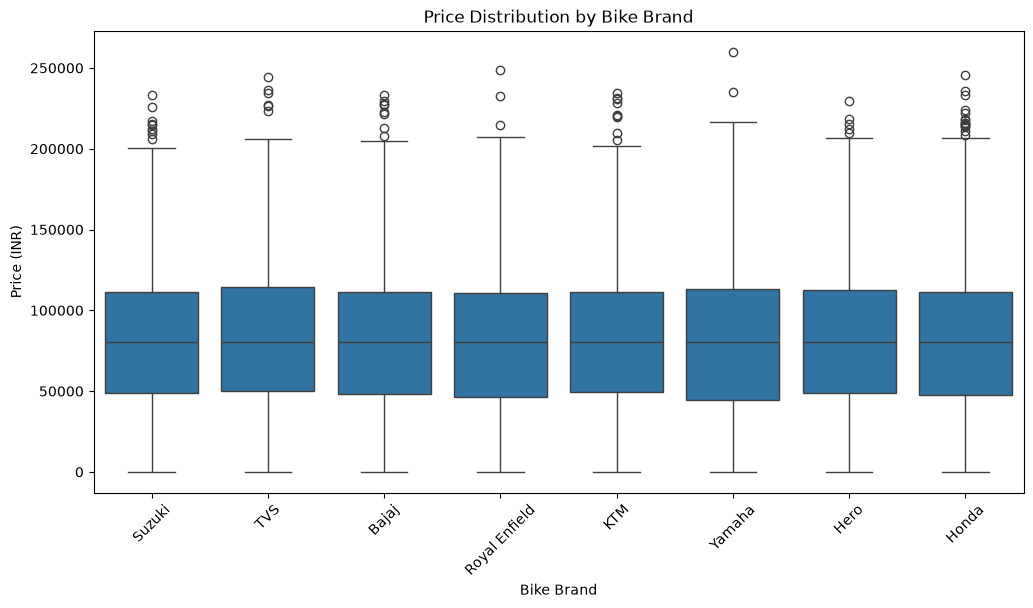

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

sns.boxplot(data=df, x="Brand", y="Price_INR")

plt.xlabel("Bike Brand")
plt.ylabel("Price (INR)")
plt.title("Price Distribution by Bike Brand")
plt.xticks(rotation=45)

plt.show()

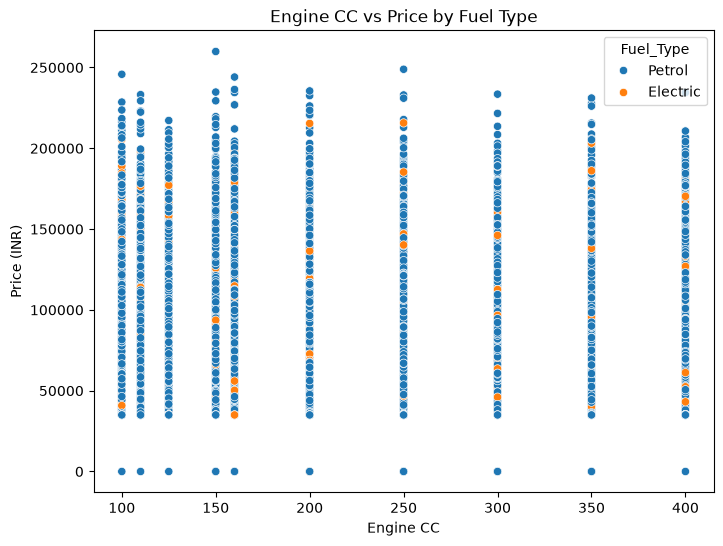

In [61]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="Engine_CC",
    y="Price_INR",
    hue="Fuel_Type"
)

plt.xlabel("Engine CC")
plt.ylabel("Price (INR)")
plt.title("Engine CC vs Price by Fuel Type")

plt.show()

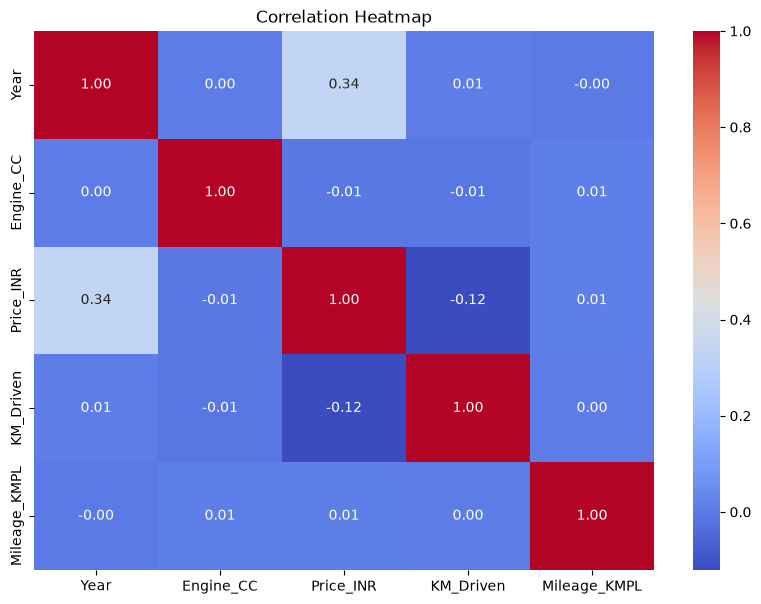

In [62]:
plt.figure(figsize=(10, 7))

correlation = df.select_dtypes(include="number").corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [2]:
import pandas as pd

df = pd.read_excel("bikesales_cleaned.xlsx")

df.head()

,Bike_ID,Brand,Model,Year,Fuel_Type,Engine_CC,Price_INR,KM_Driven,Mileage_KMPL,City
0,BK10001,Suzuki,Access 125,2018,Petrol,300,35000,44423,63.7,Salem
1,BK10002,TVS,Apache RTR 160,2025,Petrol,200,63400,14266,48.3,Chennai
2,BK10003,Bajaj,Pulsar 150,2020,Petrol,350,47300,24959,37.8,Coimbatore
3,BK10004,Suzuki,Gixxer,2025,Petrol,160,108900,25980,41.3,Salem
4,BK10005,Royal Enfield,Classic 350,2017,Petrol,300,35000,65681,55.2,Salem


In [3]:
print(df.shape)

(15000, 10)


In [4]:
brand_summary = df.groupby("Brand").agg(
    Bike_Count=("Bike_ID", "count"),
    Average_Price=("Price_INR", "mean"),
    Average_Mileage=("Mileage_KMPL", "mean"),
    Average_KM_Driven=("KM_Driven", "mean")
)

brand_summary

,Bike_Count,Average_Price,Average_Mileage,Average_KM_Driven
Brand,,,,
Bajaj,1875,84422.506667,47.940000,45161.216000
Hero,1845,85762.926829,47.922168,45547.015176
Honda,2077,85051.179586,48.166683,45690.148772
KTM,1802,85004.162042,47.935683,45632.471698
Royal Enfield,1809,83868.490879,48.019348,45784.728027
Suzuki,1851,84786.277688,48.190222,44434.137763
TVS,1844,85829.826464,48.220987,45864.729935
Yamaha,1897,84197.153400,48.273801,44820.703216


In [5]:
brand_summary["Average_Price"].idxmax()

'TVS'

In [6]:
brand_summary["Average_Mileage"].idxmax()

'Yamaha'

In [7]:
brand_summary["Bike_Count"].idxmax()

'Honda'

In [8]:
city_summary = df.groupby("City").agg(
    Bike_Count=("Bike_ID", "count"),
    Average_Price=("Price_INR", "mean"),
    Average_Mileage=("Mileage_KMPL", "mean")
)

city_summary

,Bike_Count,Average_Price,Average_Mileage
City,,,
Bengaluru,1838,85473.231774,47.843961
Chennai,1824,85172.587719,48.154715
Coimbatore,1867,84857.150509,48.212212
Hyderabad,1808,85257.466814,47.968418
Kochi,2051,85050.073135,48.269283
Madurai,1889,84312.863949,47.929751
Salem,1831,84706.990715,48.074276
Trichy,1892,84128.805497,48.210412


In [9]:
print("Total Bikes:", len(df))
print("Average Price:", df["Price_INR"].mean())
print("Average Mileage:", df["Mileage_KMPL"].mean())
print("Average Engine CC:", df["Engine_CC"].mean())
print("Average KM Driven:", df["KM_Driven"].mean())

Total Bikes: 15000
Average Price: 84866.88666666667
Average Mileage: 48.085879999999996
Average Engine CC: 213.28233333333333
Average KM Driven: 45367.41826666667
